# OpenStreetMap in bulk — Geofabrik `.osm.pbf` extracts (pbf)

This notebook teaches the **pbf** protocol of the `earthlens.osm` backend: how to read
**bulk / regional** OpenStreetMap features — every building or road in a country — from a
[Geofabrik](https://download.geofabrik.de/) `.osm.pbf` extract, rather than the small,
targeted live queries the `overpass` / `ohsome` protocols serve.

The backend downloads the regional extract once (cached on disk), reads a whole layer with
[`pyrosm`](https://pyrosm.readthedocs.io/), and clips it to your bbox. Like the other OSM
protocols it returns a pyramids `FeatureCollection` (a `geopandas.GeoDataFrame` subclass,
CRS `EPSG:4326`) and emits an **ODbL** `LicenseWarning` — credit
'© OpenStreetMap contributors' when you redistribute.

## Setup

The `pbf` protocol needs the `osm-pbf` extra (`pip install earthlens[osm-pbf]` — `pyrosm` +
`osmium`), which is kept out of `[all]` because it is heavy. `EarthLens` is the unified entry
point; `Catalog` lists the available Geofabrik regions; `matplotlib` draws the maps.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from earthlens import EarthLens
from earthlens.osm import Catalog

OUT_DIR = Path('osm_pbf_output')
OUT_DIR.mkdir(exist_ok=True)

2026-07-07 07:38:13 | INFO | pyramids.base.config | Logging is configured.


## Pick a region

A `pbf:*` query needs a `region=` — a Geofabrik region key (or a raw `continent/region`
path). The catalog ships a handful of small keys; `region_ids()` lists them. We use **Malta**
(~8.8 MB) so the download is quick.

In [2]:
Catalog().region_ids()

['andorra',
 'belgium',
 'denmark',
 'ireland-and-northern-ireland',
 'liechtenstein',
 'luxembourg',
 'malta',
 'netherlands',
 'switzerland']

## The area of interest

The request bbox clips the read. We zoom into the dense Valletta / Sliema core so the map is
readable; omit `lat_lim` / `lon_lim` to read the whole extract instead.

In [3]:
LAT_LIM = [35.88, 35.94]
LON_LIM = [14.48, 14.54]

## Every building in the area

`variables=['pbf:buildings']` maps to `pyrosm`'s building reader. The first call downloads
the Malta extract into the cross-run cache (`~/.earthlens/cache/osm_pbf/`); repeat calls
reuse it.

In [4]:
buildings = EarthLens(
    data_source='osm',
    variables=['pbf:buildings'],
    region='malta',
    lat_lim=LAT_LIM,
    lon_lim=LON_LIM,
    path=str(OUT_DIR),
).download()

len(buildings), type(buildings).__name__

2026-07-07 07:38:14.717 | INFO     | earthlens.osm.backend:_fetch_pbf:586 - Reading 'pbf:buildings' from Geofabrik region 'europe/malta' via the pyrosm engine


2026-07-07 07:38:14.888 | INFO     | earthlens.osm._pbf:download_extract:234 - Downloading Geofabrik extract https://download.geofabrik.de/europe/malta-latest.osm.pbf


europe_malta-latest.osm.pbf:   0%|          | 0.00/8.40M [00:00<?, ?B/s]

europe_malta-latest.osm.pbf:  12%|█▏        | 1.00M/8.40M [00:00<00:01, 4.54MB/s]

europe_malta-latest.osm.pbf:  71%|███████▏  | 6.00M/8.40M [00:00<00:00, 22.0MB/s]

...

2026-07-07 07:38:19.398 | INFO     | earthlens.osm.backend:_fetch:454 - pbf:buildings: fetched 7265 feature(s)


C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\osm-pbf\src\earthlens\earthlens.py:1874: LicenseWarning: OpenStreetMap data is licensed under the Open Database License (ODbL 1.0), which carries attribution and share-alike obligations: credit '(c) OpenStreetMap contributors' and license any derived database under ODbL when redistributing.
  return self.datasource.download(*args, progress_bar=progress_bar, **kwargs)


2026-07-07 07:38:20 | INFO | pyogrio._io | Created 7,265 records


2026-07-07 07:38:20.050 | INFO     | earthlens.osm.backend:download:687 - OSM download summary: 7265 feature(s) written to C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\osm-pbf\docs\examples\osm\osm_pbf_output\osm_pbf-buildings.geojson


(7265, 'FeatureCollection')

Each row is one building footprint. The `osm_id` / `osm_type` columns identify it (pyrosm's
native `id` is normalised to `osm_id` so it matches the other OSM protocols), alongside the
OSM tags pyrosm parsed.

In [5]:
cols = [c for c in ['osm_id', 'osm_type', 'building', 'name', 'geometry'] if c in buildings.columns]
buildings[cols].head()

,osm_id,osm_type,building,name,geometry
0,15684588,way,yes,Dar il-Mediterran għall-Konferenzi,"POLYGON ((14.51773 35.89992, 14.5177 35.89982,..."
1,23352829,way,cathedral,Saint John's Co-Cathedral,"POLYGON ((14.51252 35.89738, 14.51259 35.89742..."
2,24054688,way,yes,The Phoenicia,"POLYGON ((14.50701 35.8956, 14.50698 35.89577,..."
3,24054716,way,yes,Librerija Pubblika Ċentrali,"POLYGON ((14.50497 35.89653, 14.50412 35.89636..."
4,24328558,way,yes,Vittoriosa Lawn Tennis Club (VLTC),"POLYGON ((14.51019 35.87961, 14.51037 35.87991..."


### Map the footprints

A `FeatureCollection` is a GeoDataFrame, so `.plot()` maps it directly.

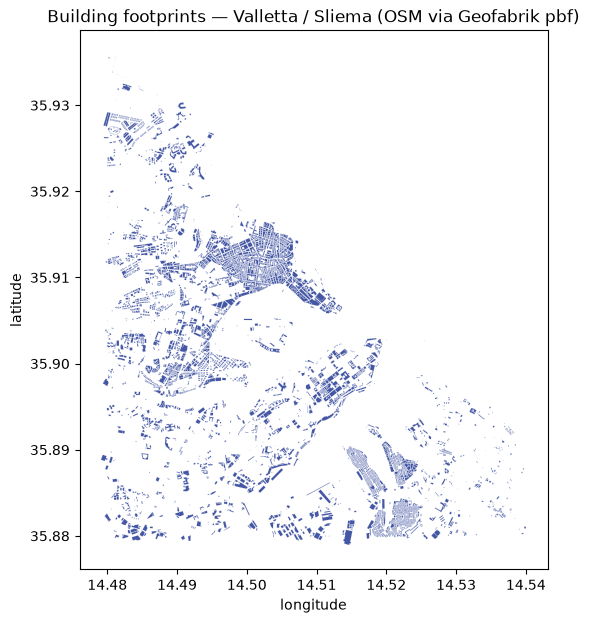

In [6]:
ax = buildings.plot(figsize=(7, 7), color='#4457a4', edgecolor='white', linewidth=0.1)
ax.set_title('Building footprints — Valletta / Sliema (OSM via Geofabrik pbf)')
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
plt.show()

## The drivable road network

`pbf:roads` reads `pyrosm`'s road network with `network_type='driving'` (from the catalog
row). The cached Malta extract is reused — no second download.

In [7]:
roads = EarthLens(
    data_source='osm',
    variables=['pbf:roads'],
    region='malta',
    lat_lim=LAT_LIM,
    lon_lim=LON_LIM,
    path=str(OUT_DIR),
).download()

len(roads), sorted(roads.geometry.geom_type.unique())

2026-07-07 07:38:21.552 | INFO     | earthlens.osm.backend:_fetch_pbf:586 - Reading 'pbf:roads' from Geofabrik region 'europe/malta' via the pyrosm engine


2026-07-07 07:38:21.553 | INFO     | earthlens.osm._pbf:download_extract:230 - OSM PBF cache hit: C:\Users\main\.earthlens\cache\osm_pbf\europe_malta-latest.osm.pbf


2026-07-07 07:38:24.189 | INFO     | earthlens.osm.backend:_fetch:454 - pbf:roads: fetched 3910 feature(s)


C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\osm-pbf\src\earthlens\earthlens.py:1874: LicenseWarning: OpenStreetMap data is licensed under the Open Database License (ODbL 1.0), which carries attribution and share-alike obligations: credit '(c) OpenStreetMap contributors' and license any derived database under ODbL when redistributing.
  return self.datasource.download(*args, progress_bar=progress_bar, **kwargs)


2026-07-07 07:38:24 | INFO | pyogrio._io | Created 3,910 records


2026-07-07 07:38:24.516 | INFO     | earthlens.osm.backend:download:687 - OSM download summary: 3910 feature(s) written to C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\osm-pbf\docs\examples\osm\osm_pbf_output\osm_pbf-roads.geojson


(3910, ['MultiLineString'])

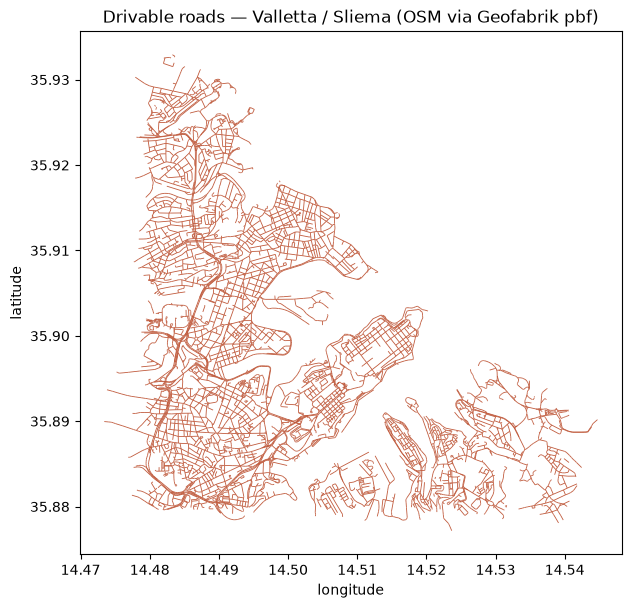

In [8]:
ax = roads.plot(figsize=(7, 7), color='#c05a3c', linewidth=0.6)
ax.set_title('Drivable roads — Valletta / Sliema (OSM via Geofabrik pbf)')
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
plt.show()

## Engines — `pyrosm` (default) vs `pyosmium`

`engine='pyrosm'` (the default, used above) reads the whole extract in memory and gives the
richest columns; it refuses a file over 4 GB. For a **continent- or planet-scale** extract
too big to hold in memory, pass `engine='pyosmium'` to stream it with bounded memory — a
coarser fallback (a slimmer `osm_id` / `osm_type` / `geometry` schema, one geometry kind per
layer). Never load `planet.osm` with `pyrosm`.

## Takeaway

- `EarthLens('osm', variables=['pbf:<layer>'], region=…, lat_lim=…, lon_lim=…).download()`
  reads a whole layer from a cached Geofabrik extract — the right tool for bulk asks that
  blow past Overpass's size limits.
- `region=` picks the extract (`Catalog().region_ids()`, or a raw `continent/region` path);
  the bbox clips the read; the extract is cached across runs.
- Use `engine='pyosmium'` for extracts too large for the in-memory `pyrosm` engine.
- Honour the **ODbL** attribution / share-alike obligation when you redistribute.